In [15]:
import os
import sys
PROJECT_ROOT = os.path.abspath('..')
sys.path.append(PROJECT_ROOT)
from circuit import Circuit
import numpy as np
import copy
import networkx as nx
import matplotlib.pyplot as plt
from repitition_code import RepititionCode
from decoder import detect_changes
from pymatching import Matching

In [ ]:
circ = Circuit(5)
circ.H(0)
circ.CNOT(0, 1)
circ.CNOT(0, 2)
circ.Z(2)

circ.CNOT(0, 3)
circ.CNOT(1, 3)
circ.CNOT(1, 4)
circ.CNOT(2, 4)

circ.measure(3)
circ.measure(4)
ss = circ.run(noise=True)


In [ ]:
from stabilizer_circuit import RepititionCode
import matplotlib.pyplot as plt

In [ ]:
er = {}
m_error_res = 10
p_error_res = 50
for m_error in range(m_error_res):
    pm = m_error/(20 * m_error_res)
    erx = {}
    for p_error in range(1, p_error_res):
        px = p_error/(2 * p_error_res)
        code = RepititionCode(3, verbose=False)  # Maybe don't need to reinstantiate this every time?
        error_rate = code.run(
            physical_error_prob=px,
            error_weight=3,
            measurement_error_prob=pm,
            shots=400,
            rounds=20,
            random_initial_state=True
        )

        erx[px] = error_rate

    er[pm] = erx

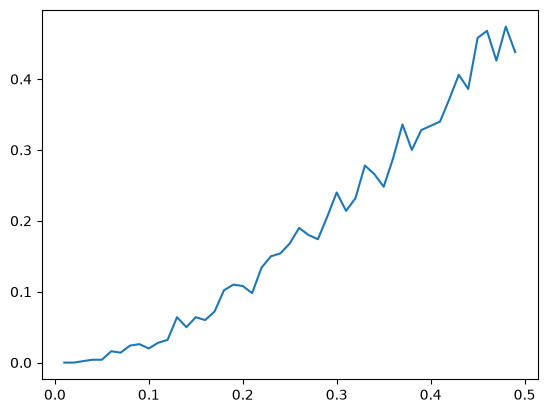

In [ ]:
plt.figure()
for k, v in er.items():
    plt.plot(v.keys(), v.values(), label=k)
    plt.legend()
plt.show()

In [ ]:
display(er)